In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge import Rouge
from nltk.translate.meteor_score import meteor_score
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import nltk
from tqdm import tqdm


model = SentenceTransformer('all-MiniLM-L6-v2')


In [ ]:
# Step 2: Read the CSV file
df = pd.read_csv('dataset/dataset_aug_train_all_new.csv')  # Replace 'your_file.csv' with your actual CSV file path
df

<!-- Metrics Computation:
ROUGE-1 F1 score is calculated for each text-augmentation pair.
METEOR is computed by splitting sentences into words and comparing them.
Plots:
Box plots are generated for each metric, grouped by language.
A scatter plot shows semantic similarity vs. syntactic difference, with points colored by language.
Interpreting the Results
Box Plots:
Look at the median (central line) to see the typical value for each metric.
The box (interquartile range) shows the spread of the middle 50% of the data.
Whiskers and outliers indicate variability and extreme cases.
Compare languages to see if one has more consistent or higher-quality augmentations.
Scatter Plot:
Points in the top-right corner (high semantic similarity, high syntactic difference) are ideal augmentations.
Clusters by language might suggest language-specific patterns in augmentation quality.
Practical Tips

By adding ROUGE and METEOR to your analysis, you get a broader view of how augmentations differ from originals, capturing both content overlap and fluency. The box plots and scatter plot provide clear, interpretable visualizations to compare metrics across languages and assess the balance between meaning preservation and structural change. This approach enhances your ability to evaluate and refine your text augmentation process effectively. -->

In [5]:

languages = [col.split('_')[1] for col in df.columns if col.startswith('augment_') and col.endswith('_hels')]

# ### Step 3: Compute embeddings for original texts
original_embeddings = model.encode(df['text'].tolist())

# Initialize Rouge calculator
rouge = Rouge()

# Initialize list to store results
data = []

# Define smoothing function for BLEU to avoid zero-score warnings
smoothie = SmoothingFunction().method1

# ### Step 4: Compute metrics for each language with a progress bar
total_iterations = len(languages) * len(df)  # Total number of sentence-language pairs
pbar = tqdm(total=total_iterations, desc="Computing metrics")  # Initialize progress bar

for lang in languages:
    pbar.set_description(f"Processing {lang}")  # Update description to current language
    augment_col = f'augment_{lang}_hels'
    
    # Compute embeddings for augmented texts (done once per language)
    augment_embeddings = model.encode(df[augment_col].tolist())
    
    for i in range(len(df)):
        original_text = df['text'][i]
        augment_text = df[augment_col][i]
        
        # **BLEU score with smoothing**
        bleu = sentence_bleu([original_text.split()], augment_text.split(), smoothing_function=smoothie)
        
        # **ROUGE-1 F1 score**
        rouge_scores = rouge.get_scores(augment_text, original_text)
        rouge_1_f1 = rouge_scores[0]['rouge-1']['f']
        
        # **METEOR score**
        meteor = meteor_score([original_text.split()], augment_text.split())
        
        # **Semantic similarity** (cosine similarity of embeddings)
        sem_sim = cosine_similarity([original_embeddings[i]], [augment_embeddings[i]])[0][0]
        
        # Store results
        data.append({
            'language': lang,
            'sentence_id': i,
            'bleu': bleu,
            'rouge_1_f1': rouge_1_f1,
            'meteor': meteor,
            'semantic_sim': sem_sim,
            'syntactic_diff': 1 - bleu  # Syntactic difference as 1 - BLEU
        })
        
        # Update the progress bar
        pbar.update(1)

pbar.close()  # Close the progress bar after completion


Processing cy: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 875000/875000 [15:56<00:00, 915.26it/s]


In [6]:
results_df = pd.DataFrame(data)
results_df.to_csv('dataset/OutputComparsion.csv', index=False)


/tmp/ipykernel_24425/2248319900.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(xtick, medians[xtick] + 0.02, f'{medians[xtick]:.2f}',


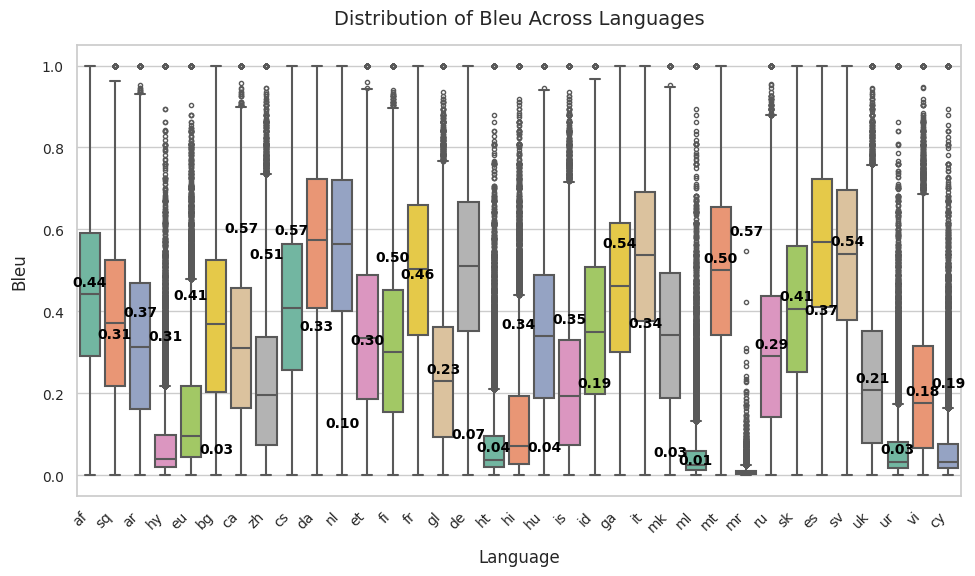

/tmp/ipykernel_24425/2248319900.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(xtick, medians[xtick] + 0.02, f'{medians[xtick]:.2f}',


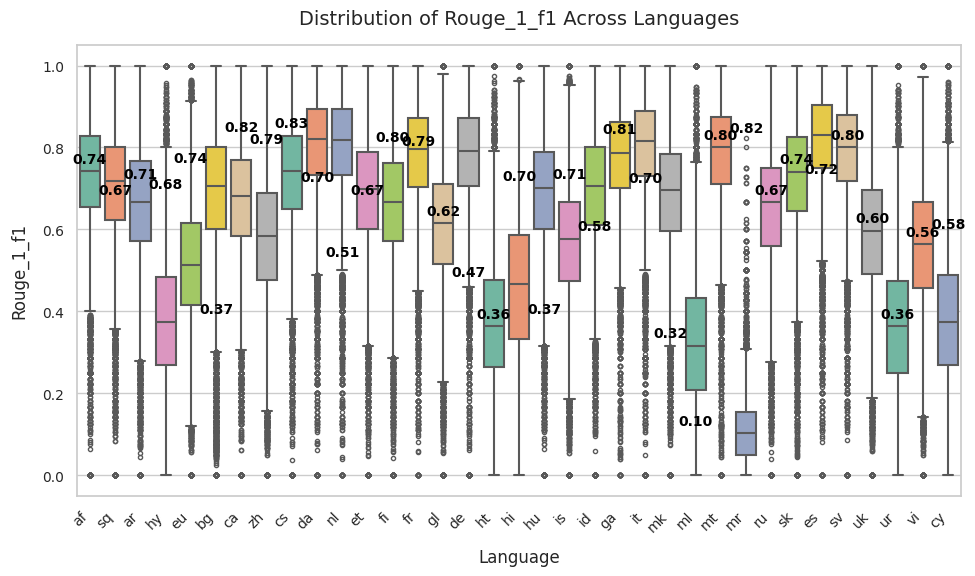

/tmp/ipykernel_24425/2248319900.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(xtick, medians[xtick] + 0.02, f'{medians[xtick]:.2f}',


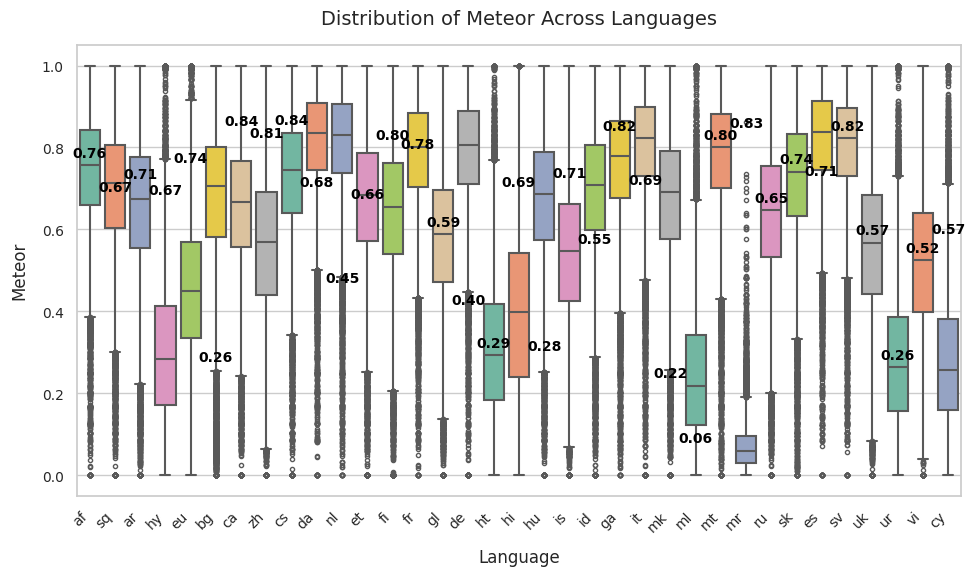

/tmp/ipykernel_24425/2248319900.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(xtick, medians[xtick] + 0.02, f'{medians[xtick]:.2f}',


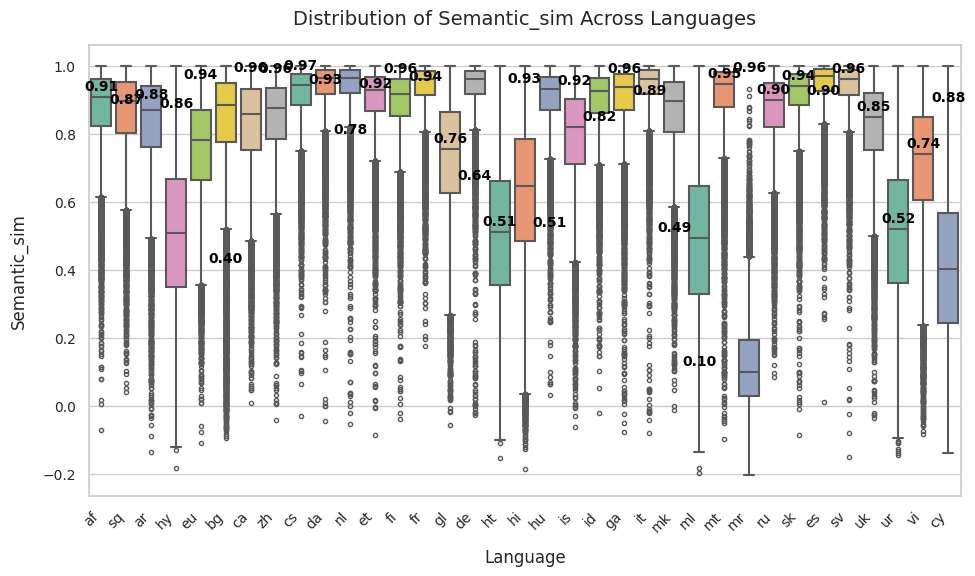

/tmp/ipykernel_24425/2248319900.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(xtick, medians[xtick] + 0.02, f'{medians[xtick]:.2f}',


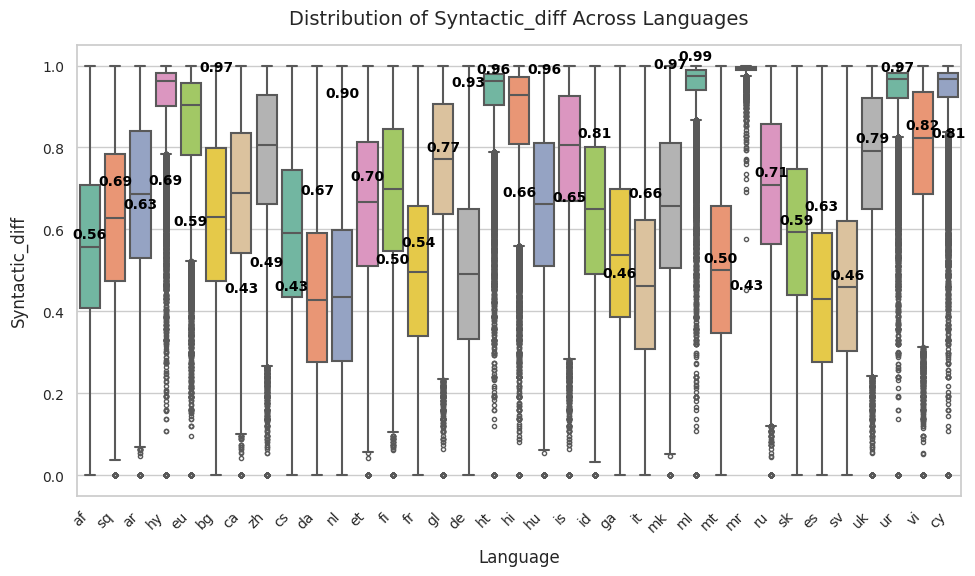

/home/mtech/torch/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


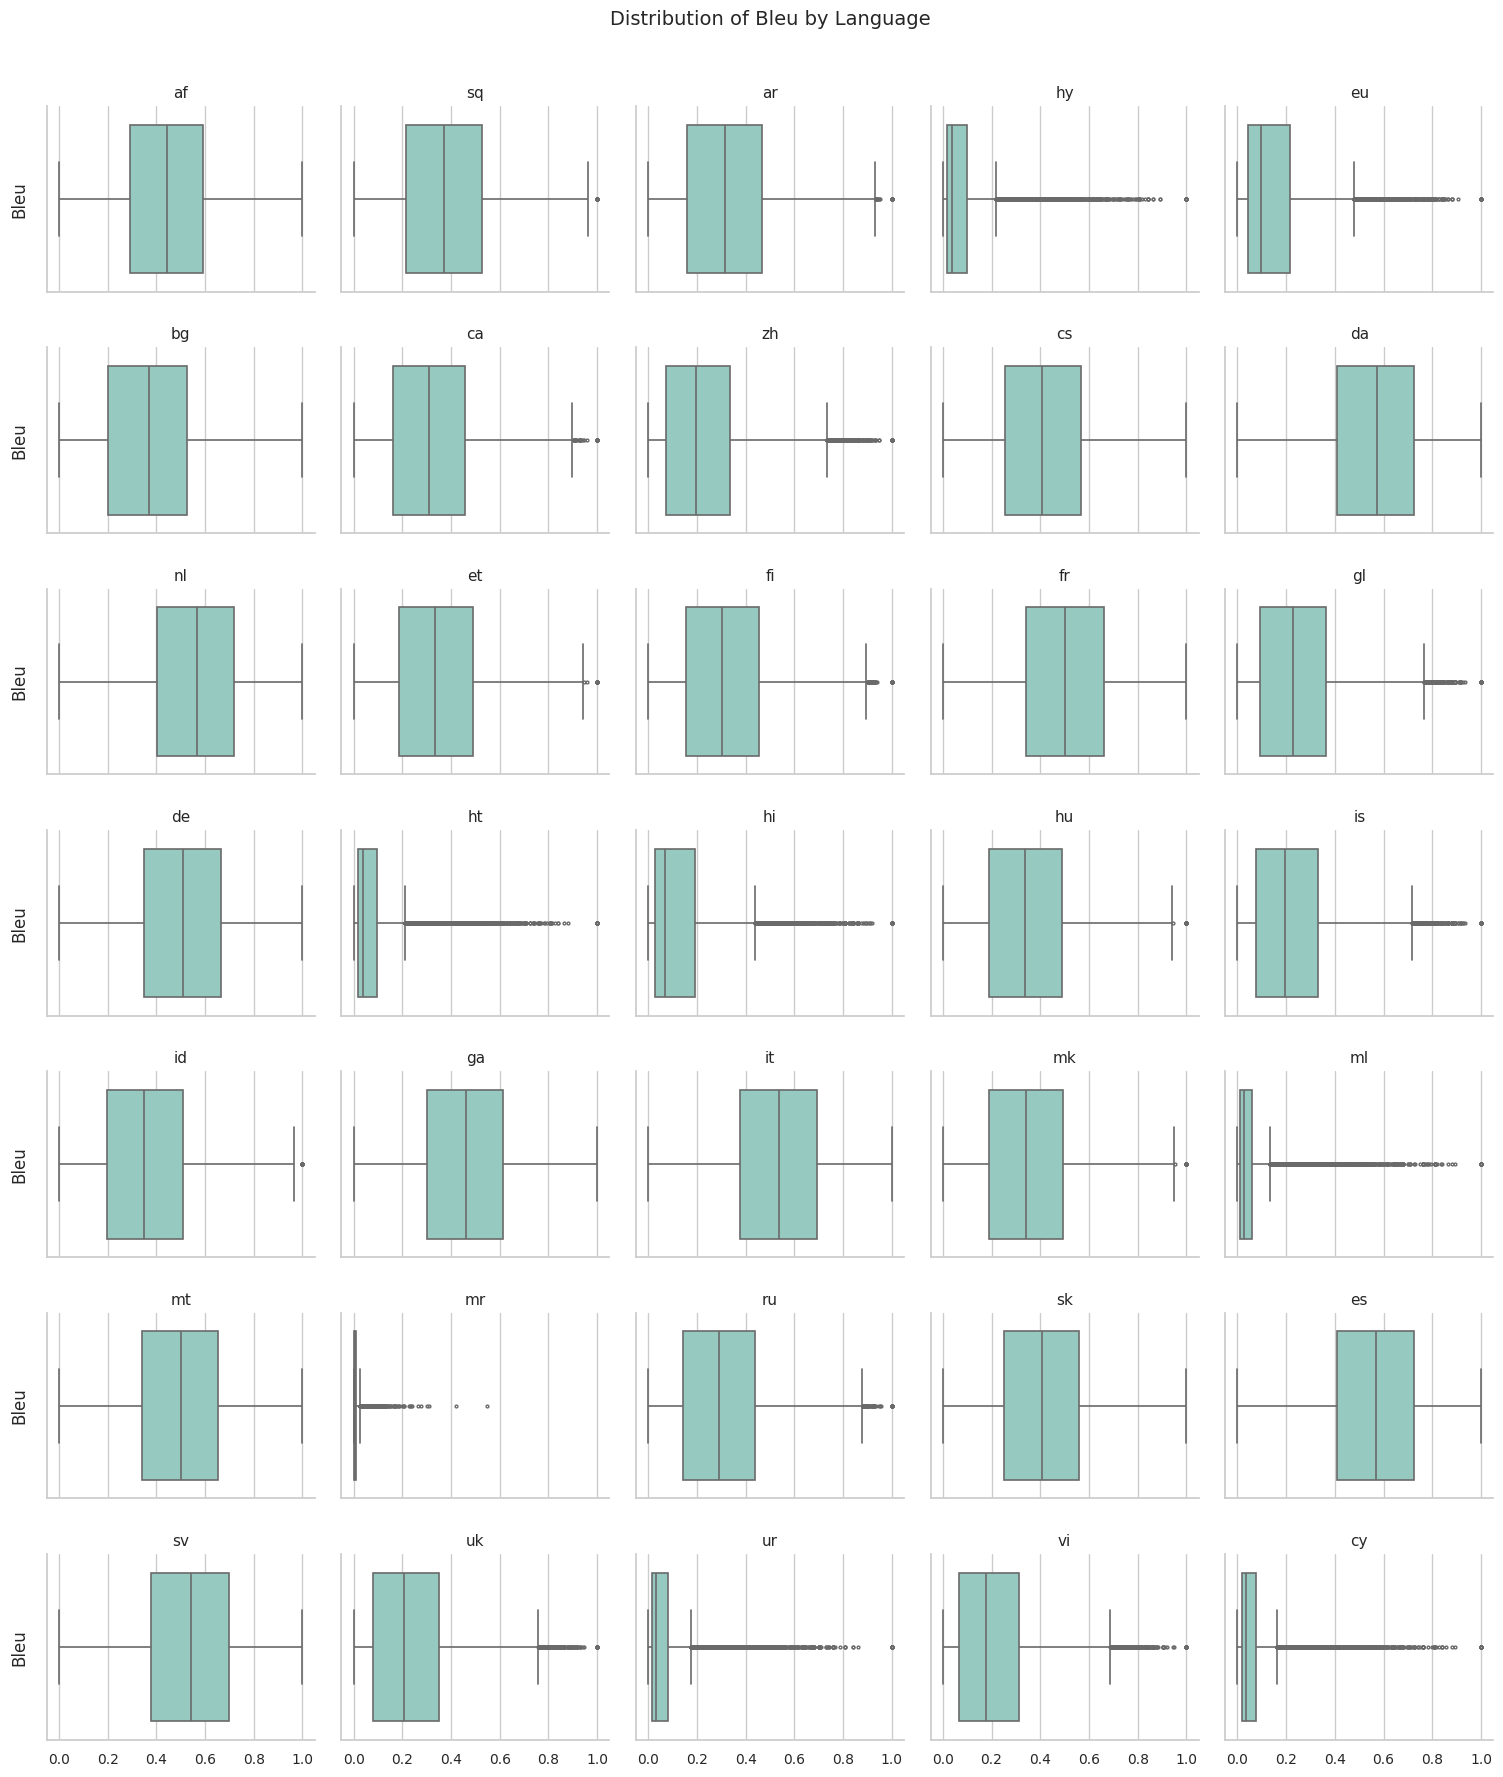

/home/mtech/torch/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


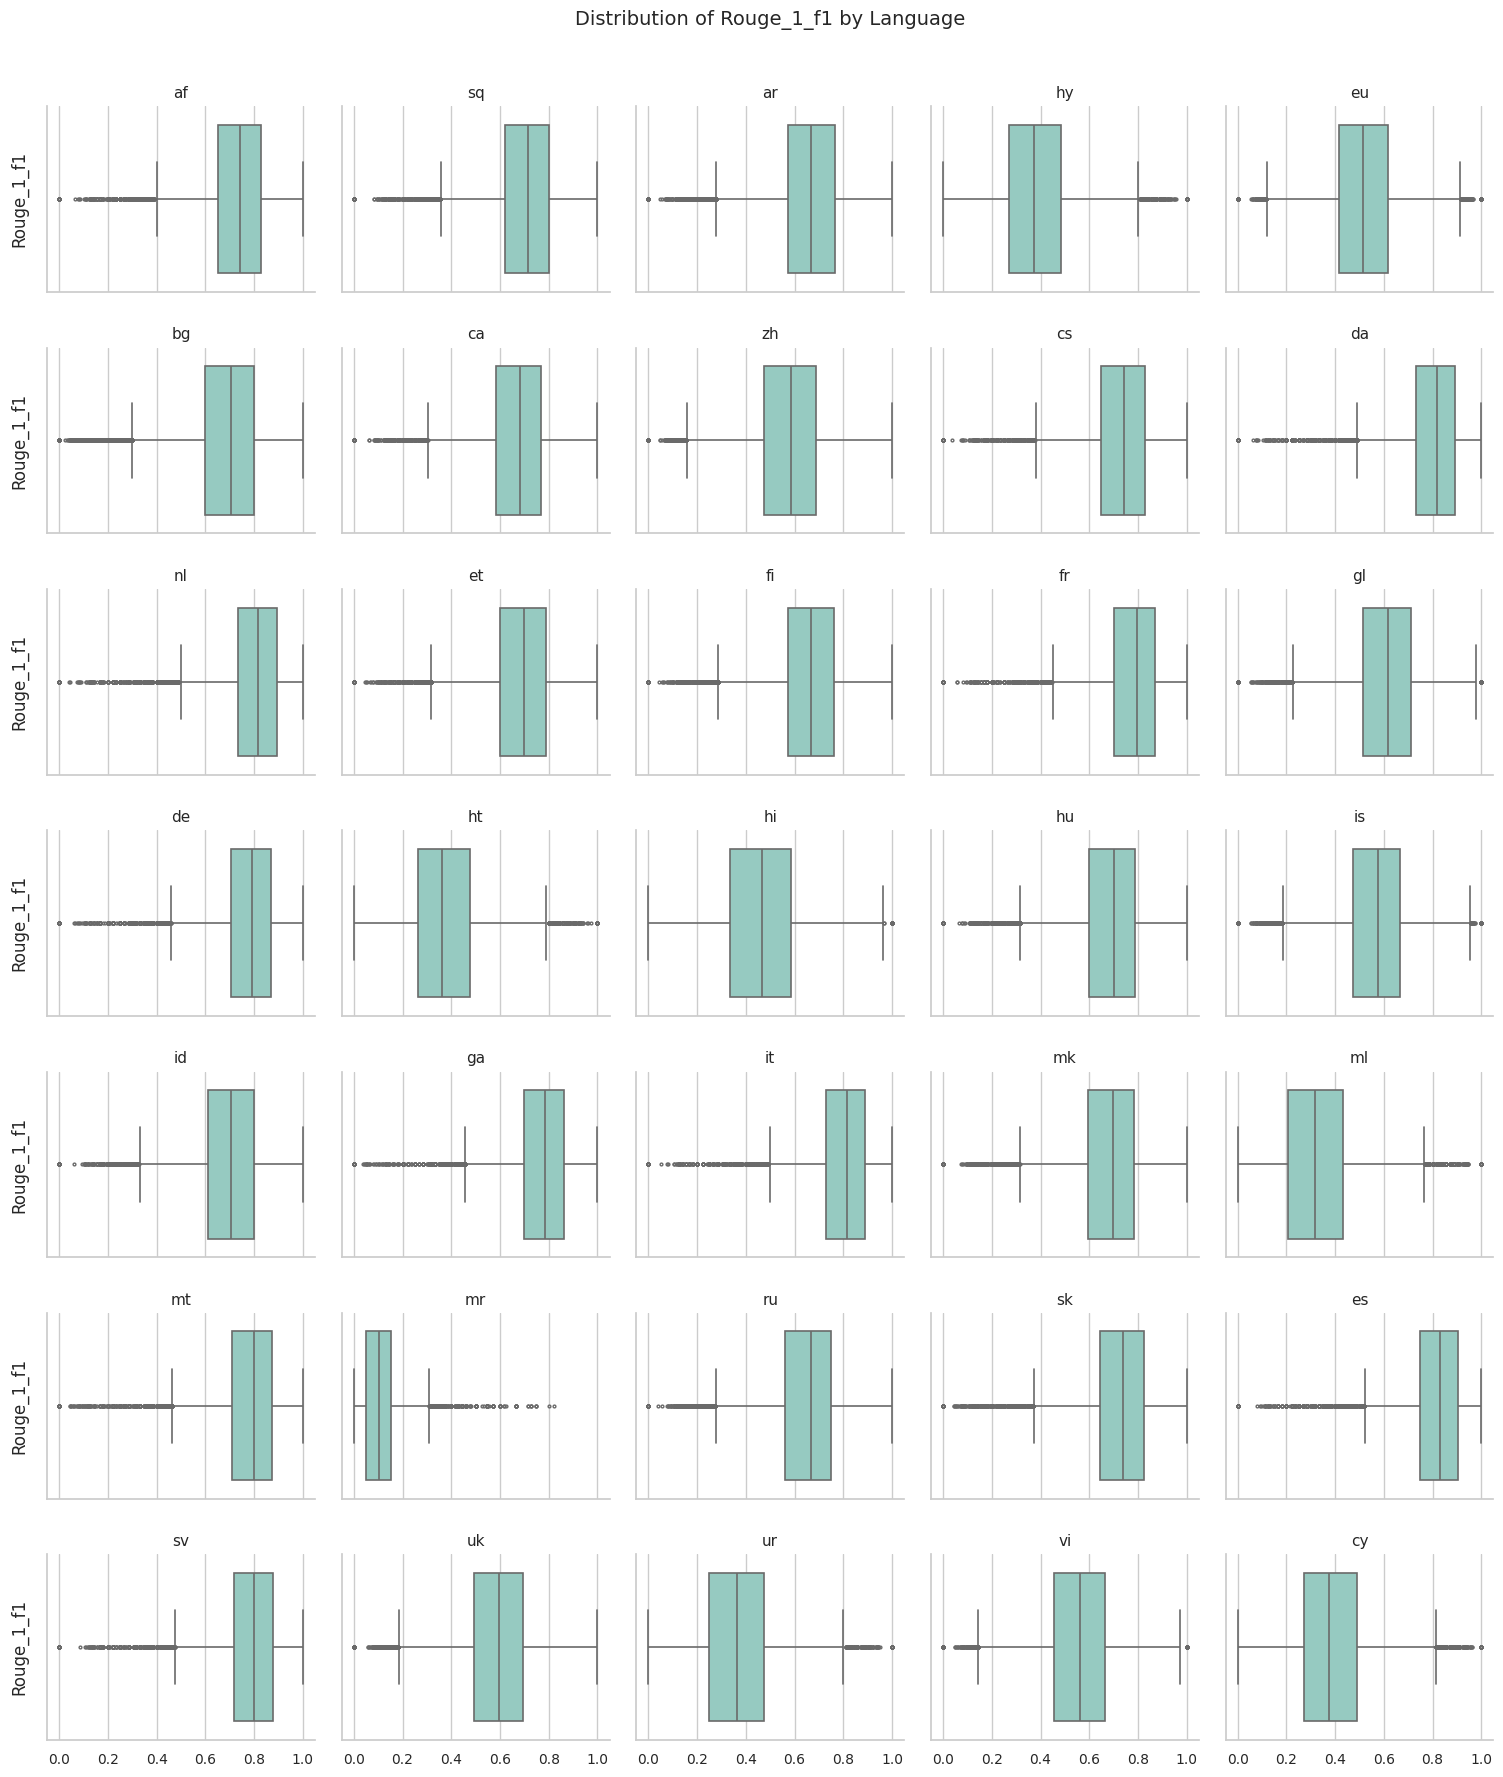

/home/mtech/torch/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


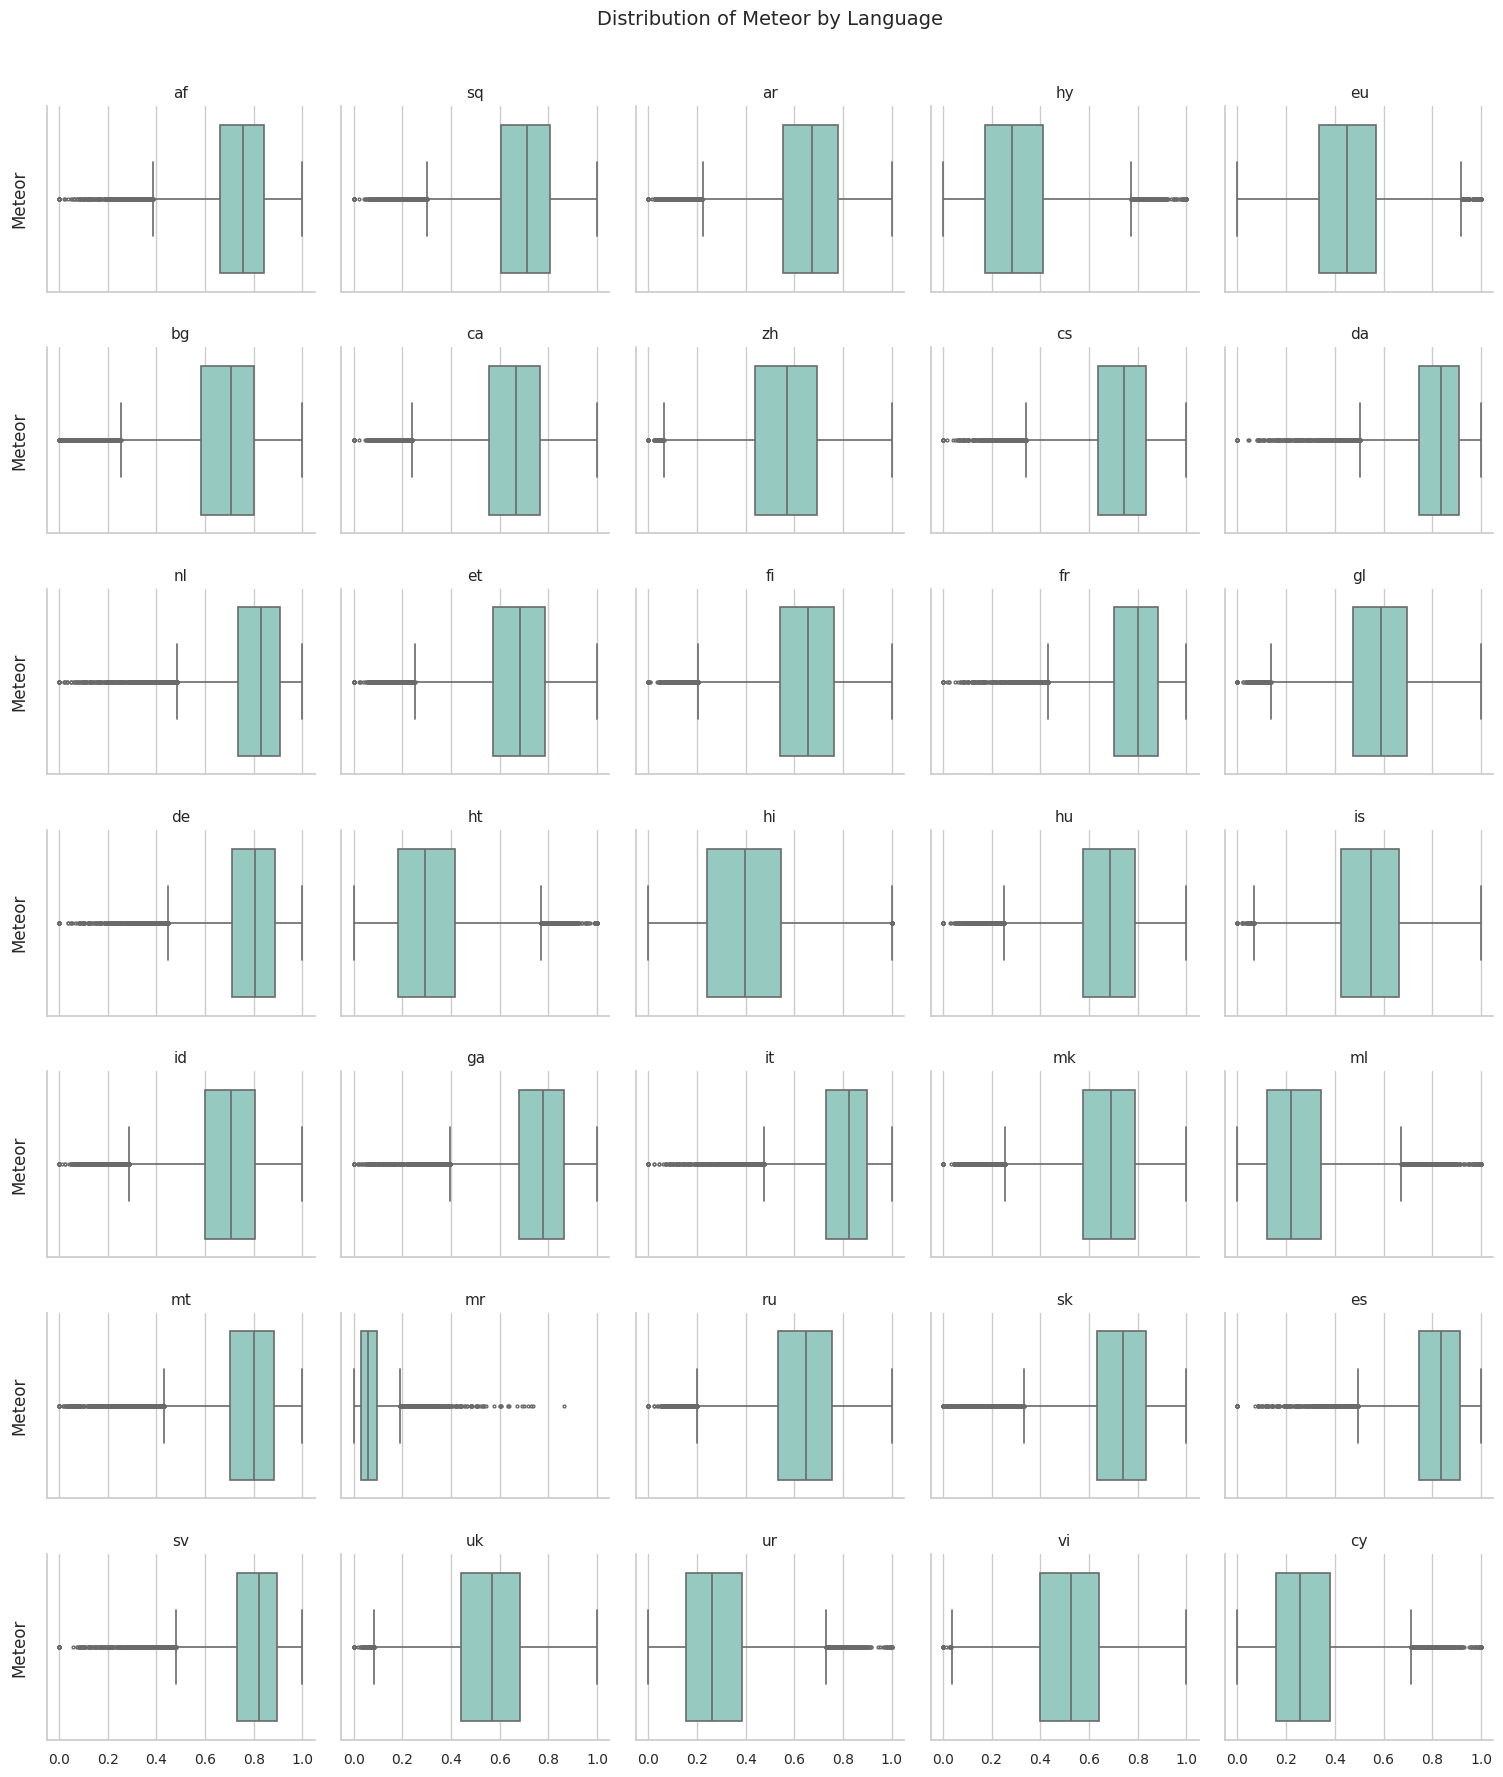

/home/mtech/torch/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


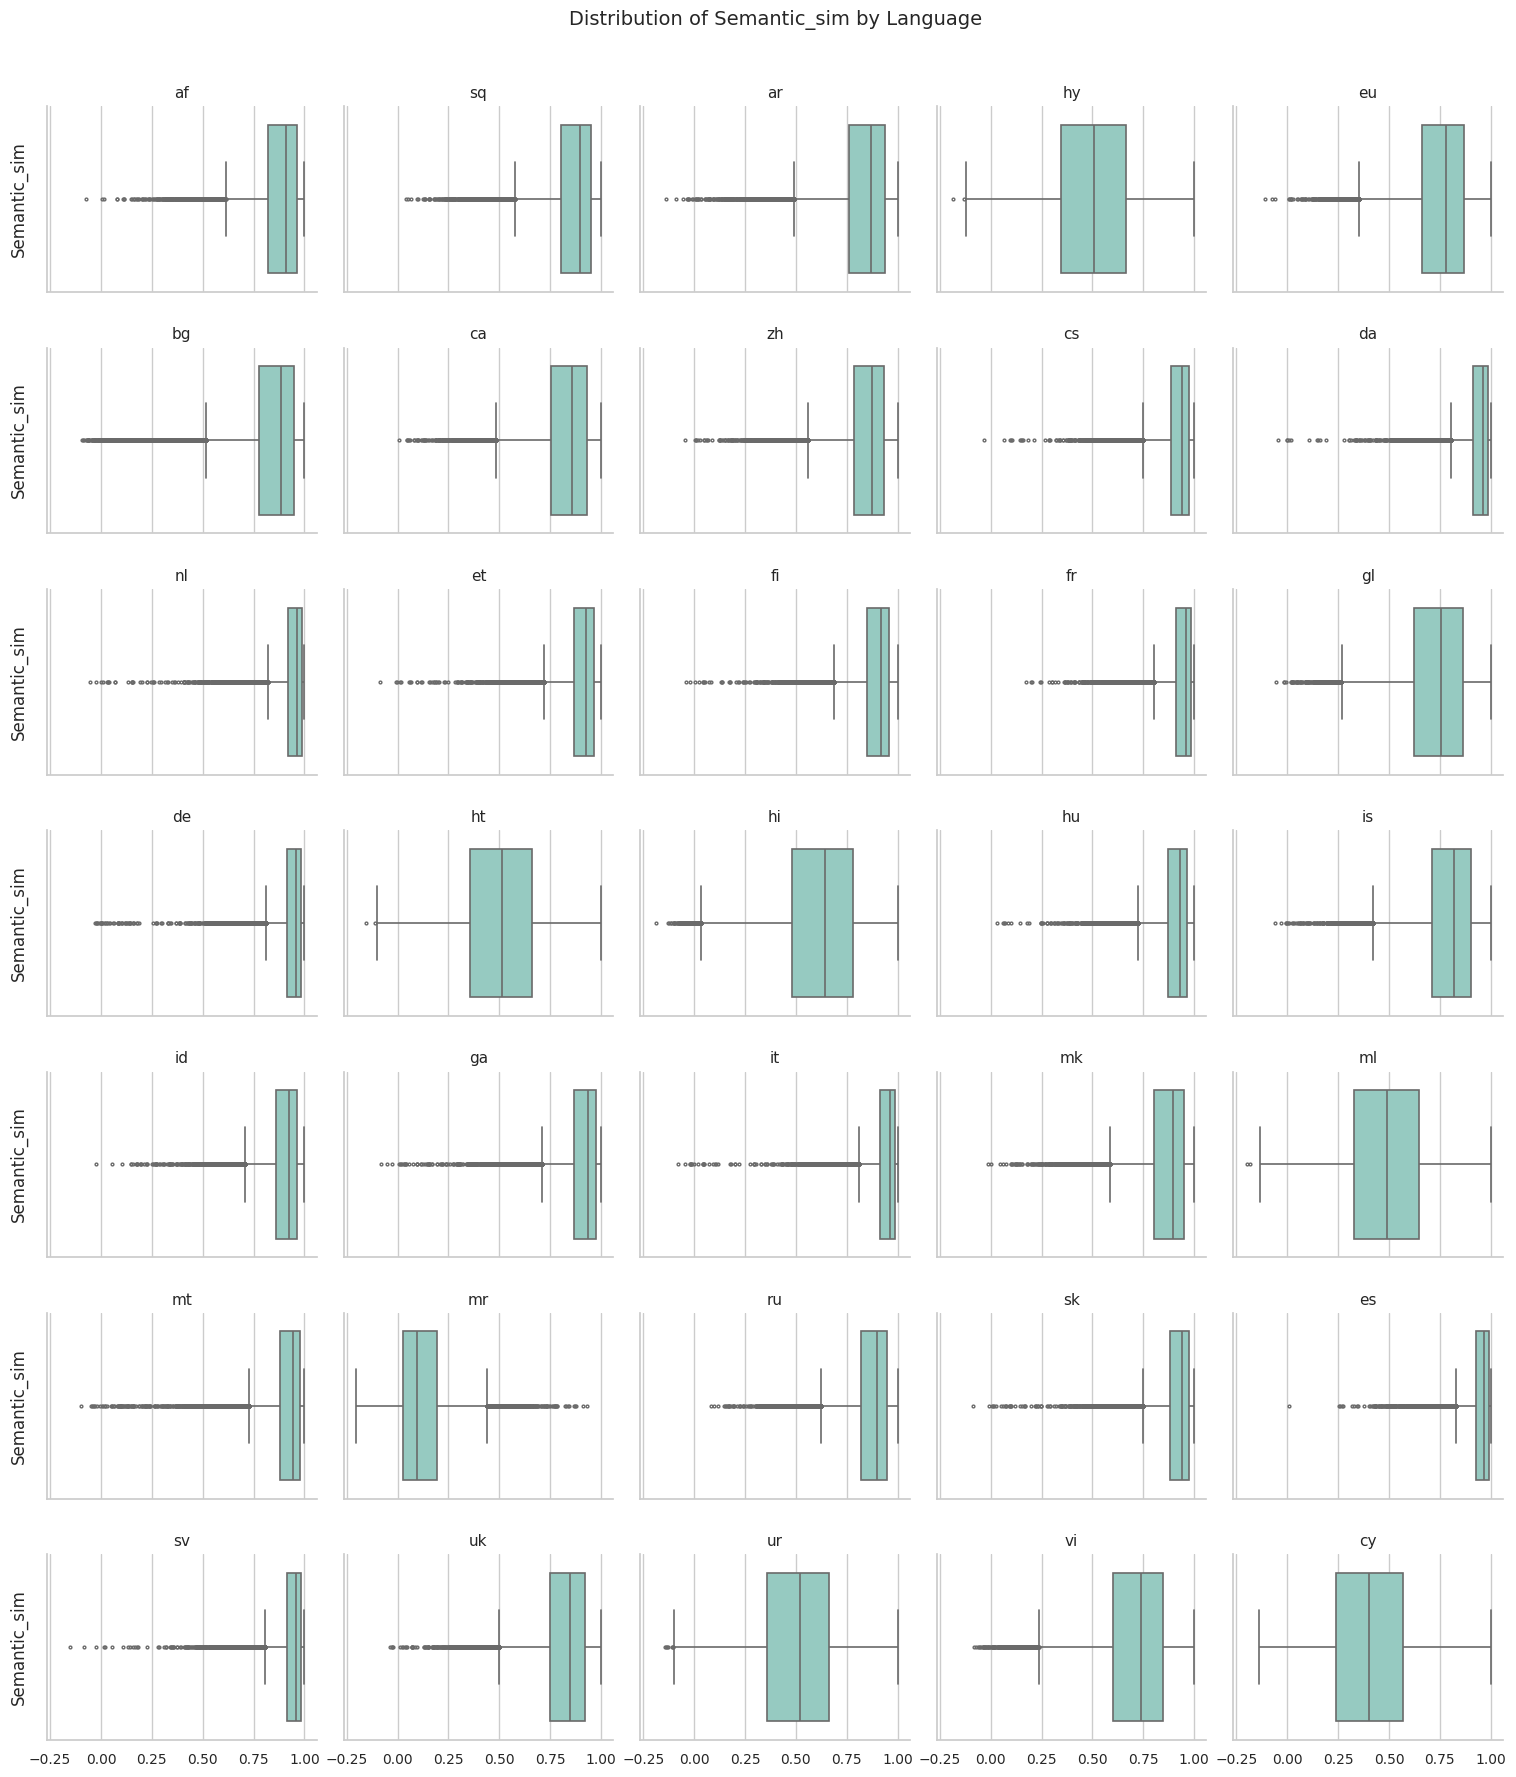

/home/mtech/torch/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


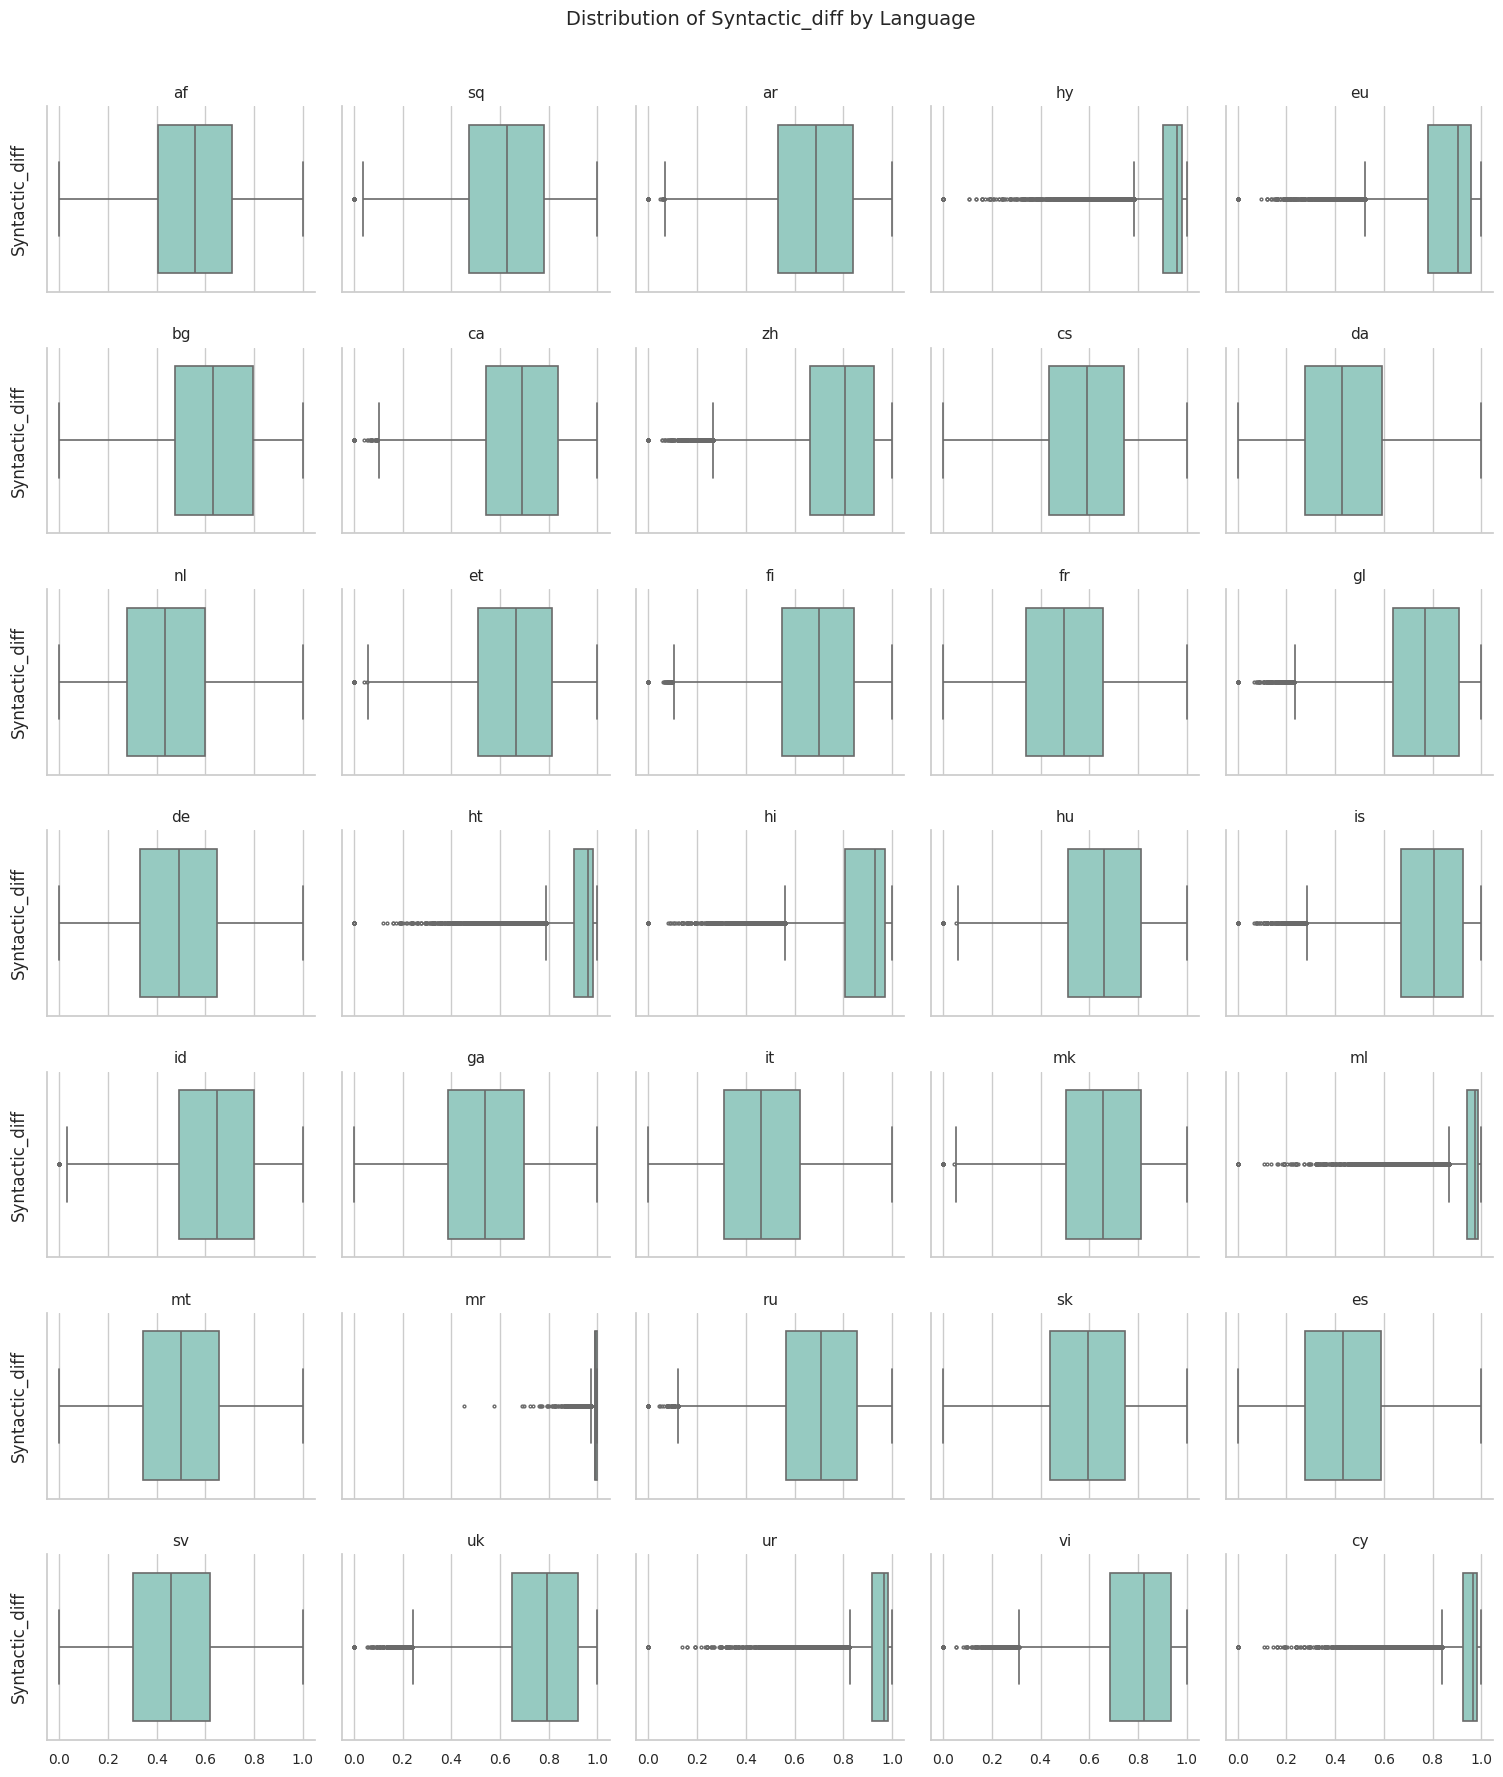

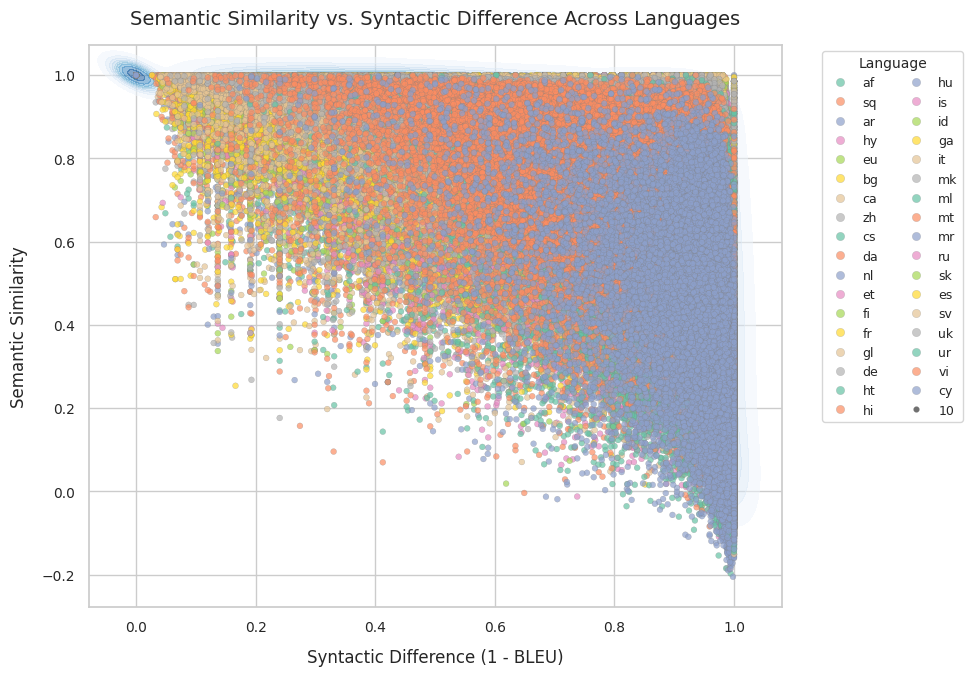

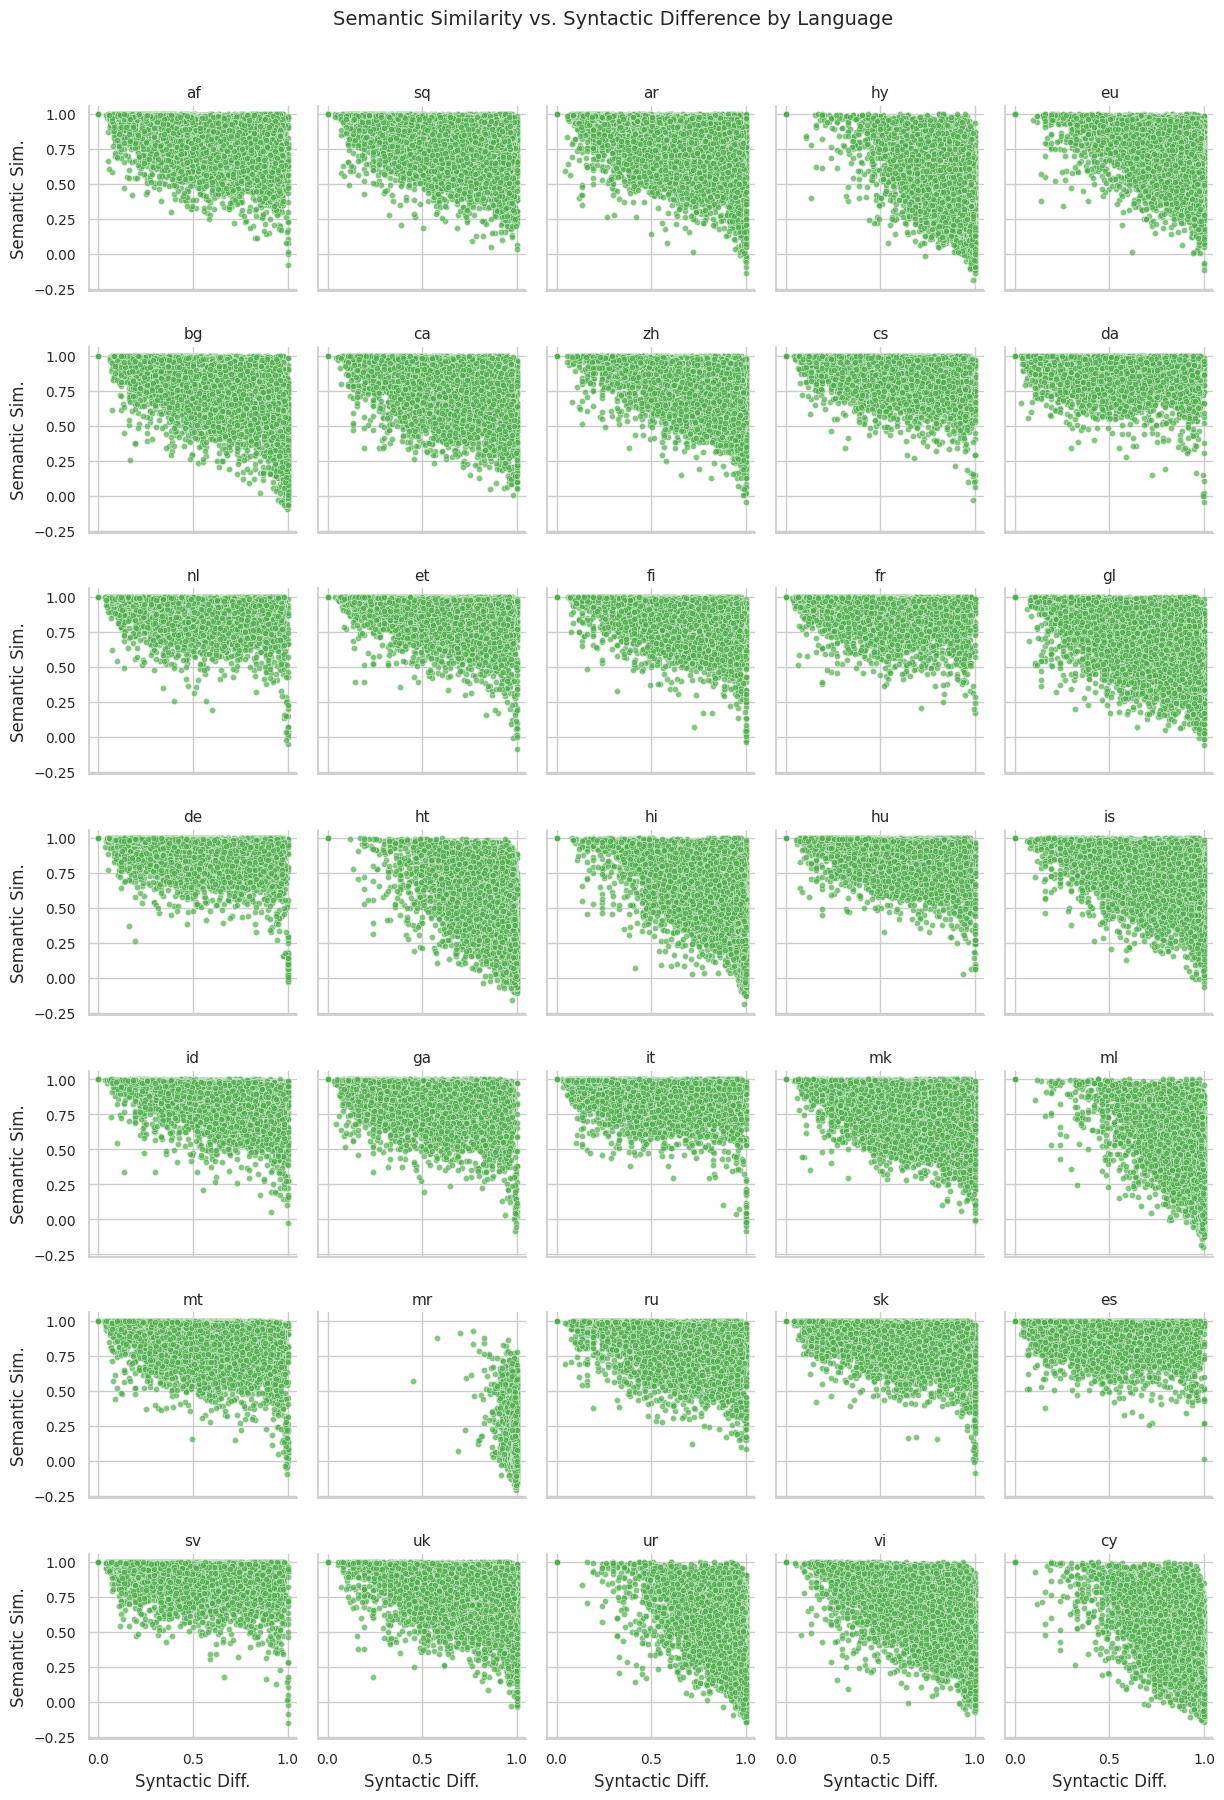

In [7]:

# Assume results_df is already created with your data
# results_df = pd.DataFrame(data)

# Define metrics and publication-ready styling
metrics = ['bleu', 'rouge_1_f1', 'meteor', 'semantic_sim', 'syntactic_diff']
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({'axes.titlesize': 14, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

# **Box plots with statistical annotations**
for metric in metrics:
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(x='language', y=metric, hue='language', data=results_df, palette='Set2', legend=False, 
                     linewidth=1.5, fliersize=3)
    plt.title(f'Distribution of {metric.capitalize()} Across Languages', pad=15)
    plt.xlabel('Language', labelpad=10)
    plt.ylabel(metric.capitalize(), labelpad=10)
    plt.xticks(rotation=45, ha='right')
    
    # Add median annotations for clarity
    medians = results_df.groupby('language')[metric].median()
    for xtick in ax.get_xticks():
        ax.text(xtick, medians[xtick] + 0.02, f'{medians[xtick]:.2f}', 
                horizontalalignment='center', size=10, color='black', weight='semibold')
    
    plt.tight_layout()
    # plt.savefig(f'boxplot_{metric}.png', dpi=300, bbox_inches='tight')  # Save for paper
    plt.show()

# **Faceted box plots for many languages**
for metric in metrics:
    g = sns.FacetGrid(results_df, col="language", col_wrap=5, height=2.5, aspect=1.2, sharey=True)
    g.map(sns.boxplot, metric, color='#8dd3c7', linewidth=1.2, fliersize=2)
    g.set_titles("{col_name}", size=11)
    g.set_axis_labels("", metric.capitalize())
    g.fig.suptitle(f'Distribution of {metric.capitalize()} by Language', y=1.03, fontsize=14)
    g.fig.subplots_adjust(wspace=0.1, hspace=0.3)
    # plt.savefig(f'faceted_boxplot_{metric}.png', dpi=300, bbox_inches='tight')
    plt.show()

# **Enhanced scatter plot with density contours**
plt.figure(figsize=(10, 7))
sns.kdeplot(x='syntactic_diff', y='semantic_sim', data=results_df, fill=True, cmap='Blues', alpha=0.5)
sns.scatterplot(x='syntactic_diff', y='semantic_sim', hue='language', size=10, alpha=0.7, 
                palette='Set2', data=results_df, edgecolor='gray', linewidth=0.2)
plt.title('Semantic Similarity vs. Syntactic Difference Across Languages', pad=15)
plt.xlabel('Syntactic Difference (1 - BLEU)', labelpad=10)
plt.ylabel('Semantic Similarity', labelpad=10)
n_languages = len(results_df['language'].unique())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Language", fontsize=9, 
           title_fontsize=10, ncol=2 if n_languages > 8 else 1)
plt.tight_layout()
# plt.savefig('scatter_semantic_vs_syntactic.png', dpi=300, bbox_inches='tight')
plt.show()

# **Faceted scatter plot for detailed analysis**
g = sns.FacetGrid(results_df, col="language", col_wrap=5, height=2.5, aspect=1, sharex=True, sharey=True)
g.map(sns.scatterplot, 'syntactic_diff', 'semantic_sim', alpha=0.7, color='#4daf4a', s=20)
g.set_titles("{col_name}", size=11)
g.set_axis_labels('Syntactic Diff.', 'Semantic Sim.')
g.fig.suptitle('Semantic Similarity vs. Syntactic Difference by Language', y=1.03, fontsize=14)
g.fig.subplots_adjust(wspace=0.1, hspace=0.3)
# plt.savefig('faceted_scatter_semantic_vs_syntactic.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
import re
import torch
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
import os
import sys

# Suppress specific logging from transformers and accelerate
import logging

MODEL_NAME = "meta-llama/Llama-3.2-1B"
BATCH_SIZE = 64  # Adjust this based on your GPU memory capacity

# Load tokenizer and model
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")

# Move model to the correct device (cuda or cpu)
model.to(device)

# Define prompt template
PROMPT_TEMPLATE = """
You are evaluating the quality of a sentence augmentation.
Given the original sentence and its augmented version, provide three scores:
1. **Semantic Preservation (0-100):** How well does the augmented sentence preserve the original meaning?
2. **Error Severity (0-100):** How incorrect is the augmentation? (Higher means more incorrect)
3. **Diversity Score (0-100):** How different is the augmentation structurally while still being valid?

Return scores in the format: `Semantic: X, Error: Y, Diversity: Z`.

Original: "{original}"
Augmented: "{augmented}"

Scores:
"""

# Function to generate scores for a batch using LLaMA
def get_scores_batch(originals, augmenteds):
    # Ensure tokenizer has a pad_token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token  # or tokenizer.add_special_tokens({'pad_token': '[PAD]'})

    prompts = [PROMPT_TEMPLATE.format(original=o, augmented=a) for o, a in zip(originals, augmenteds)]

    # Set padding to left for decoder-only models
    tokenizer.padding_side = "left"
    
    # Now you can use it for tokenization
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

    # Tokenizing the prompts
    # inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
    
    # Set pad_token_id explicitly to eos_token_id to avoid the warning
    pad_token_id = tokenizer.eos_token_id

    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=50, 
            pad_token_id=pad_token_id
        )
    
    responses = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    
    # Extract scores using regex for each response
    scores = []
    for response in responses:
        match = re.search(r"Semantic:\s*([\d.]+),\s*Error:\s*([\d.]+),\s*Diversity:\s*([\d.]+)", response)
        if match:
            scores.append((float(match.group(1)), float(match.group(2)), float(match.group(3))))
        else:
            scores.append((None, None, None))
    
    return scores

# Assuming df is defined earlier in your code
# If not, add: df = pd.read_csv('your_file.csv') or similar

# Identify augmentation columns
augmentation_cols = [col for col in df.columns if col.startswith("augment_")]

# Initialize results list
results = []


In [7]:

# Process augmentations in batches
for col in augmentation_cols:
    original_texts = df["text"].tolist()
    augmented_texts = df[col].tolist()
    
    # Filter out invalid entries
    valid_pairs = [(o, a) for o, a in zip(original_texts, augmented_texts) 
                  if isinstance(a, str) and not pd.isna(a)]
    if not valid_pairs:
        continue
    
    original_batch = [pair[0] for pair in valid_pairs]
    augmented_batch = [pair[1] for pair in valid_pairs]
    
    # Process in batches
    for i in tqdm(range(0, len(valid_pairs), BATCH_SIZE), desc=f"Processing {col}"):
        batch_orig = original_batch[i:i + BATCH_SIZE]
        batch_aug = augmented_batch[i:i + BATCH_SIZE]
        
        batch_scores = get_scores_batch(batch_orig, batch_aug)
        
        # Append results with the column name
        for j, (semantic, error, diversity) in enumerate(batch_scores):
            results.append({
                "sentence_id": i + j,
                "augmentation_column": col,  # Column name added here
                "semantic_score": semantic,
                "error_score": error,
                "diversity_score": diversity
            })


# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df.to_csv('dataset/BERTEval.csv', index=False)


Processing augment_af_hels:   6%|█████▊                                                                                    | 25/391 [01:13<17:49,  2.92s/it]


KeyboardInterrupt: 

In [ ]:
import re
# import torch
# import pandas as pd
# from tqdm import tqdm
# from transformers import AutoTokenizer, AutoModelForCausalLM
# import os
# import sys

# # Suppress specific logging from transformers and accelerate
# import logging

# MODEL_NAME = "meta-llama/Llama-3.2-1B"

# # Load tokenizer and model
# device = "cuda" if torch.cuda.is_available() else "cpu"
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")

# # Move model to the correct device (cuda or cpu)
# model.to(device)

# # Define prompt template
# PROMPT_TEMPLATE = """
# You are evaluating the quality of a sentence augmentation.
# Given the original sentence and its augmented version, provide three scores:
# 1. **Semantic Preservation (0-100):** How well does the augmented sentence preserve the original meaning?
# 2. **Error Severity (0-100):** How incorrect is the augmentation? (Higher means more incorrect)
# 3. **Diversity Score (0-100):** How different is the augmentation structurally while still being valid?

# Return scores in the format: `Semantic: X, Error: Y, Diversity: Z`.

# Original: "{original}"
# Augmented: "{augmented}"

# Scores:
# """

# # Function to generate scores using LLaMA
# def get_scores(original, augmented):
#     prompt = PROMPT_TEMPLATE.format(original=original, augmented=augmented)
#     inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    
#     # Set pad_token_id explicitly to eos_token_id to avoid the warning
#     pad_token_id = tokenizer.eos_token_id
    
#     with torch.no_grad():
#         output = model.generate(
#             **inputs, 
#             max_new_tokens=50, 
#             pad_token_id=pad_token_id  # Explicitly set the pad_token_id
#         )
    
#     response = tokenizer.decode(output[0], skip_special_tokens=True)
    
#     # Extract scores using regex
#     match = re.search(r"Semantic:\s*([\d.]+),\s*Error:\s*([\d.]+),\s*Diversity:\s*([\d.]+)", response)
#     if match:
#         return float(match.group(1)), float(match.group(2)), float(match.group(3))
#     else:
#         return None, None, None  # Handle failure cases


# # Identify augmentation columns
# augmentation_cols = [col for col in df.columns if col.startswith("augment_")]

# # Initialize results list
# results = []

# # Process augmentations
# for i, row in tqdm(df.iterrows(), total=len(df)):


#     original = row["text"]
    
#     for col in augmentation_cols:
#         augmented = row[col]
        
#         # Skip missing or non-English augmentations (optional filter)
#         if pd.isna(augmented) or not isinstance(augmented, str):
#             continue
        
#         # Get model-generated scores
#         semantic, error, diversity = get_scores(original, augmented)
        
#         # Append to results
#         results.append({
#             "sentence_id": i,
#             "augmentation_column": col,
#             "semantic_score": semantic,
#             "error_score": error,
#             "diversity_score": diversity
#         })

# # Convert results to DataFrameca
# results_df = pd.DataFrame(results)
# print(results_df)

